# M4-B2 — Vision PCB Defect (binôme async)

Auteurs : `Théo` — Date : `08/07/2026`

**Conventions** :
- `random_state=42`
- Pas de `print` excessif
- `Co-authored-by:` sur les commits significatifs

In [19]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

sys.path.append('..')  # racine du repo → permet les imports « package » src.*
from src.load_data import CLASSES, get_dataloaders

DATA_DIR = Path('../data/pcb_defect_sample')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

Device : cpu


## 1. EDA dataset PCB (~1h binôme)

- Distribution des 7 classes (déséquilibre ?)
- Visualisation 7×3 subplot (3 exemples par classe)
- Notes : qualité d'image, variabilité intra-classe, ambiguïtés

Total images: 2100

Distribution par classe:
- ok        : 300
- open      : 300
- short     : 300
- mousebite : 300
- spur      : 300
- copper    : 300
- pin_hole  : 300

Imbalance ratio max/min = 1.00


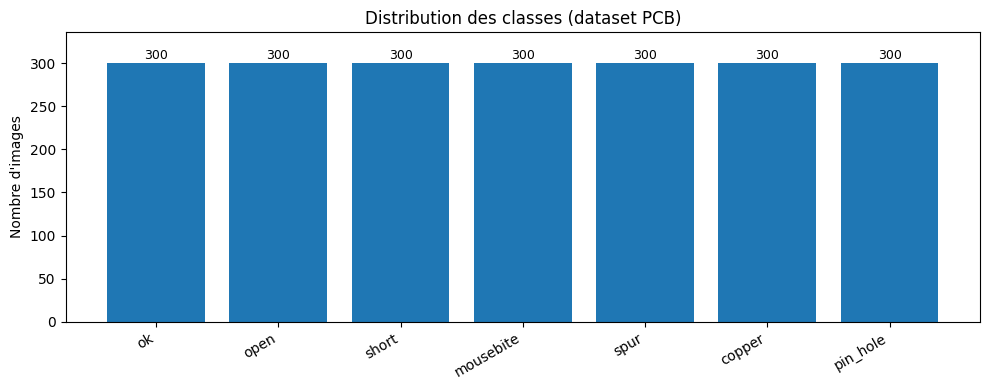

In [20]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Comptage des images par classe
all_samples = []
for cls_name in CLASSES:
    cls_dir = DATA_DIR / cls_name
    if cls_dir.is_dir():
        all_samples.extend((p, cls_name) for p in sorted(cls_dir.glob('*.png')))

counts = Counter(label for _, label in all_samples)
print(f"Total images: {sum(counts.values())}")
print("\nDistribution par classe:")
for cls_name in CLASSES:
    print(f"- {cls_name:10s}: {counts.get(cls_name, 0)}")

# Bar chart
x = np.arange(len(CLASSES))
y = np.array([counts.get(c, 0) for c in CLASSES])

plt.figure(figsize=(10, 4))
bars = plt.bar(x, y)
plt.xticks(x, CLASSES, rotation=30, ha='right')
plt.ylabel('Nombre d\'images')
plt.title('Distribution des classes (dataset PCB)')

for bar, value in zip(bars, y):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(int(value)),
        ha='center',
        va='bottom',
        fontsize=9,
    )

if y.max() > 0:
    imbalance_ratio = y.max() / max(1, y.min())
    plt.ylim(0, y.max() * 1.12)
    print(f"\nImbalance ratio max/min = {imbalance_ratio:.2f}")

plt.tight_layout()
plt.show()

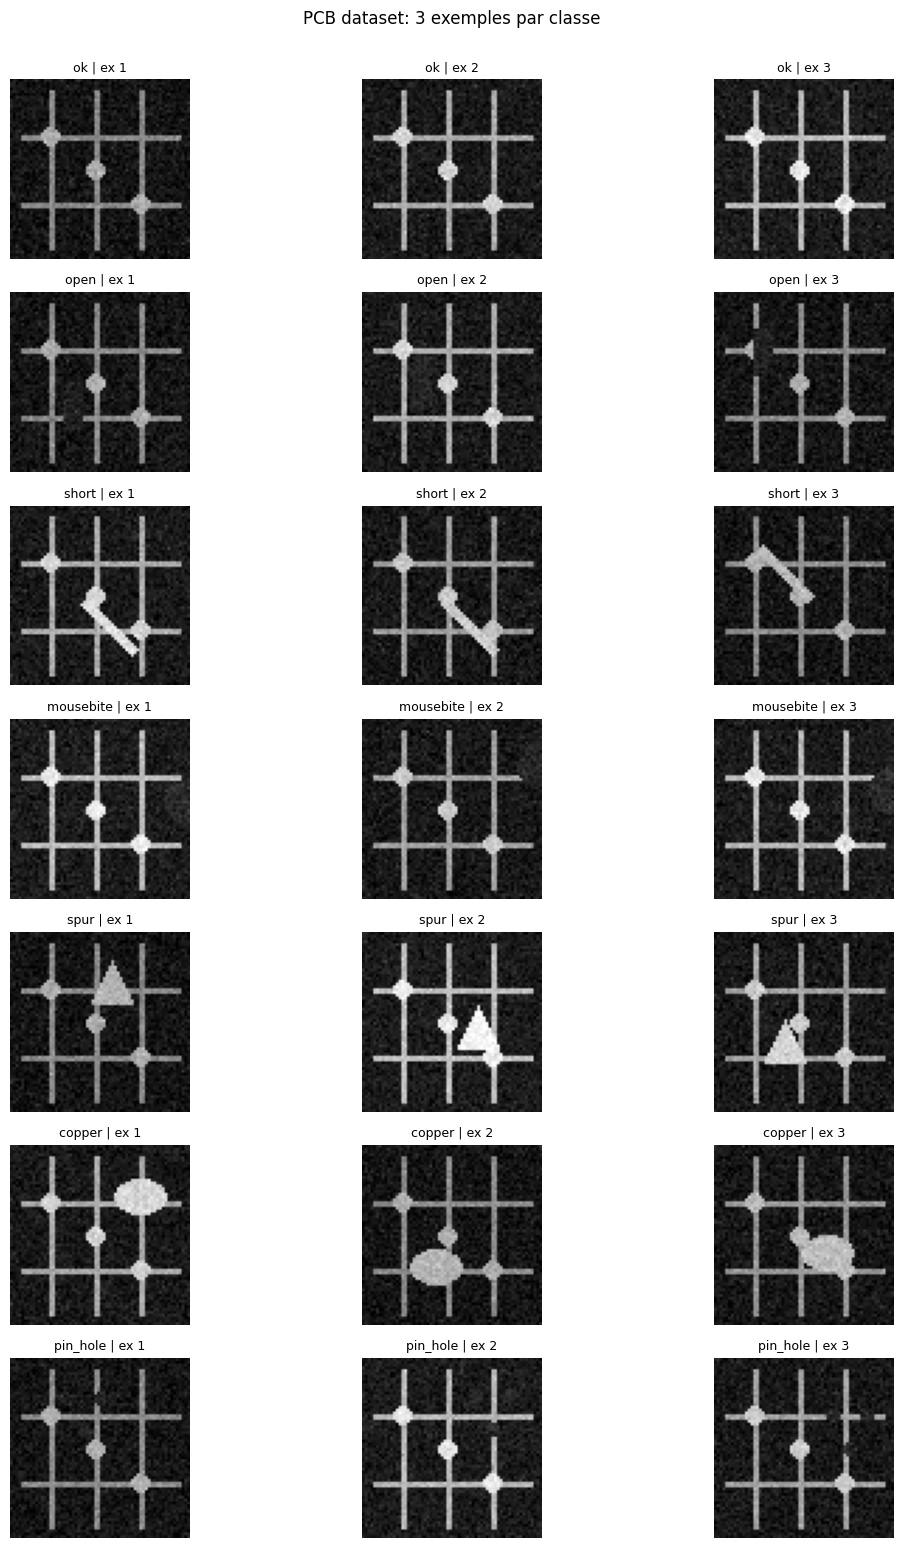

Notes qualitatives (proxy):
- Moyenne intensité: proche de 0 = images globalement sombres; proche de 1 = claires.
- Ecart-type intensité: élevé = plus de texture/contraste intra-image.
- ok        : mean=0.180, std=0.212
- open      : mean=0.164, std=0.192
- short     : mean=0.183, std=0.219
- mousebite : mean=0.194, std=0.227
- spur      : mean=0.197, std=0.237
- copper    : mean=0.191, std=0.228
- pin_hole  : mean=0.175, std=0.207


In [21]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 3 exemples par classe en grille 7x3
rng = np.random.default_rng(42)
n_rows = len(CLASSES)
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2.2 * n_rows))
if n_rows == 1:
    axes = np.array([axes])

quality_stats = []

for row, cls_name in enumerate(CLASSES):
    cls_dir = DATA_DIR / cls_name
    paths = sorted(cls_dir.glob('*.png')) if cls_dir.is_dir() else []

    if len(paths) == 0:
        for col in range(n_cols):
            ax = axes[row, col]
            ax.axis('off')
            ax.set_title(f"{cls_name} (vide)", fontsize=9)
        quality_stats.append((cls_name, np.nan, np.nan))
        continue

    selected_idx = rng.choice(len(paths), size=min(n_cols, len(paths)), replace=False)
    selected = [paths[i] for i in selected_idx]

    means, stds = [], []
    for col in range(n_cols):
        ax = axes[row, col]
        if col < len(selected):
            img = Image.open(selected[col]).convert('L')
            arr = np.asarray(img, dtype=np.float32) / 255.0
            means.append(float(arr.mean()))
            stds.append(float(arr.std()))

            ax.imshow(arr, cmap='gray', vmin=0, vmax=1)
            ax.set_title(f"{cls_name} | ex {col + 1}", fontsize=9)
            ax.axis('off')
        else:
            ax.axis('off')

    quality_stats.append((
        cls_name,
        float(np.mean(means)) if means else np.nan,
        float(np.mean(stds)) if stds else np.nan,
    ))

plt.suptitle('PCB dataset: 3 exemples par classe', y=1.002, fontsize=12)
plt.tight_layout()
plt.show()

print('Notes qualitatives (proxy):')
print('- Moyenne intensité: proche de 0 = images globalement sombres; proche de 1 = claires.')
print('- Ecart-type intensité: élevé = plus de texture/contraste intra-image.')
for cls_name, m, s in quality_stats:
    if np.isnan(m):
        print(f"- {cls_name:10s}: aucune image trouvée")
    else:
        print(f"- {cls_name:10s}: mean={m:.3f}, std={s:.3f}")

- Qualité d’image : images globalement nettes, fond homogène, peu de bruit ; quelques variations de luminosité entre classes.
- Variabilité intra-classe : la classe ok est assez homogène ; les classes de défaut montrent des formes et positions plus variées.
- Ambiguïtés : certaines images open vs short et mousebite vs spur peuvent se ressembler visuellement sur un seul patch.
- Impact modèle : risque de confusion entre classes proches ; utile de regarder une matrice de confusion après entraînement.
- Action recommandée : conserver une augmentation légère (rotation faible, contraste) et vérifier les erreurs par classe.

### Suivi des runs Option B (versioning)

Principe :
- Ne pas modifier la cellule de code d'une version déjà exécutée.
- Créer une nouvelle cellule pour chaque nouvelle version (V2, V3, ...).
- Sauvegarder avec un nom de modèle distinct par version.

| Version | Configuration | Epochs | Train time (s) | Test loss | Test acc | Latence ms (CPU) | Modèle | Notes |
|---|---|---:|---:|---:|---:|---:|---|---|
| V1 | ResNet18 freeze backbone + FC, lr=1e-3, batch=64 | 5 | 185.78 | 1.4024 | 0.5079 | 32.808 | ../models/option_b_resnet18_frozen.pth | Baseline transfer learning |
| V2 | Fine-tuning partiel layer4 + fc, lr(layer4)=1e-4 lr(fc)=1e-3, batch=64 | 10 | 491.81 | 0.5571 | 0.7905 | 35.165 | ../models/option_b_resnet18_v2_layer4_fc.pth | Best val_acc=0.7460 à l'epoch 8, léger overfit ensuite |

## 2. Implémentation de l'option B

Cf. `decisions.md` pour le choix (A / B / C).

- Option A : `src/option_a_cnn.py`
- Option B : `src/option_b_transfer.py`
- Option C : `src/option_c_clip.py`

### Version 1 - Baseline (backbone gelé)

Objectif de cette version:
- Établir une baseline simple en transfer learning.
- Geler tout le backbone ResNet18 et entraîner uniquement la tête de classification (fc).
- Mesurer accuracy, temps d'entraînement et latence pour comparaison avec les versions suivantes.

In [22]:
import time
import json
from datetime import datetime, timezone
from hashlib import sha256
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from src.load_data import PCBDefectDataset
from src.option_a_cnn import train_one_epoch, evaluate
from src.option_b_transfer import build_resnet18_classifier, get_transfer_transforms

# 1) Dataloaders avec transforms adaptées à ResNet (224x224, 3 canaux, normalisation ImageNet)
torch.manual_seed(42)
transfer_ds = PCBDefectDataset(DATA_DIR, transform=get_transfer_transforms(image_size=224))

n_total = len(transfer_ds)
n_val = int(n_total * 0.15)
n_test = int(n_total * 0.15)
n_train = n_total - n_val - n_test

split_gen = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = torch.utils.data.random_split(
    transfer_ds, [n_train, n_val, n_test], generator=split_gen
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

# 2) Modèle transfer learning (backbone freezé, tête ré-entraînée pour 7 classes)
model = build_resnet18_classifier(n_classes=len(CLASSES), freeze_backbone=True).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam((p for p in model.parameters() if p.requires_grad), lr=1e-3)

# 3) Entraînement
epochs = 5
history = []
t0 = time.perf_counter()

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
    history.append((train_loss, train_acc, val_loss, val_acc))
    print(
        f"Epoch {epoch}/{epochs} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

train_seconds = time.perf_counter() - t0
print(f"Temps d'entraînement total : {train_seconds:.2f} s")

# 4) Évaluation test
test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"Loss test : {test_loss:.4f}")
print(f"Accuracy test : {test_acc:.4f}")

# 5) Latence moyenne d'inférence (batch=1)
model.eval()
single_x, _ = test_ds[0]
single_x = single_x.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    for _ in range(10):
        _ = model(single_x)

iters = 100
lat_start = time.perf_counter()
with torch.no_grad():
    for _ in range(iters):
        _ = model(single_x)
lat_ms = (time.perf_counter() - lat_start) / iters * 1000
print(f"Latence moyenne inférence (batch=1, device={DEVICE}) : {lat_ms:.3f} ms")

# 6) Sauvegarde modèle + métadonnées
model_path = Path('../models/option_b_resnet18_frozen.pth')
model_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), model_path)
print(f"Modèle sauvegardé : {model_path}")

best_epoch_v1 = int(np.argmax([h[3] for h in history]) + 1)
best_val_acc_v1 = float(max(h[3] for h in history))
best_val_loss_v1 = float(min(h[2] for h in history))

meta_v1 = {
    "format": "torch_state_dict",
    "saved_model_path": str(model_path),
    "model_name": "resnet18_transfer_frozen",
    "n_classes": len(CLASSES),
    "classes": CLASSES,
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_fingerprint_sha256": sha256(str(DATA_DIR).encode()).hexdigest(),
    "versions": {
        "python": sys.version,
        "torch": torch.__version__,
    },
    "training_config": {
        "batch_size": 64,
        "learning_rate": 1e-3,
        "epochs": epochs,
        "optimizer": "Adam",
        "loss_function": "CrossEntropyLoss",
        "freeze_backbone": True,
        "unfrozen_parts": ["fc"],
    },
    "metrics": {
        "train_time_s": float(train_seconds),
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
        "latency_ms_batch1_cpu_or_device": float(lat_ms),
        "best_val_epoch": best_epoch_v1,
        "best_val_acc": best_val_acc_v1,
        "best_val_loss": best_val_loss_v1,
    },
}

meta_path_v1 = Path('../models/option_b_resnet18_frozen_meta.json')
with open(meta_path_v1, 'w', encoding='utf-8') as f:
    json.dump(meta_v1, f, indent=2, ensure_ascii=False)
print(f"Métadonnées sauvegardées : {meta_path_v1}")

Epoch 1/5 | train_loss=1.9352 train_acc=0.2054 | val_loss=1.9302 val_acc=0.1683
Epoch 2/5 | train_loss=1.7085 train_acc=0.3850 | val_loss=1.7399 val_acc=0.3048
Epoch 3/5 | train_loss=1.5622 train_acc=0.4796 | val_loss=1.5182 val_acc=0.4825
Epoch 4/5 | train_loss=1.4392 train_acc=0.5265 | val_loss=1.4371 val_acc=0.4635
Epoch 5/5 | train_loss=1.3745 train_acc=0.5279 | val_loss=1.3627 val_acc=0.5048
Temps d'entraînement total : 303.76 s
Loss test : 1.4024
Accuracy test : 0.5079
Latence moyenne inférence (batch=1, device=cpu) : 77.781 ms
Modèle sauvegardé : ..\models\option_b_resnet18_frozen.pth
Métadonnées sauvegardées : ..\models\option_b_resnet18_frozen_meta.json


### Version 2 - Fine-tuning partiel (layer4 + fc)

Objectif de cette version:
- Débloquer layer4 en plus de la tête fc pour mieux adapter ResNet au domaine PCB.
- Garder un learning rate plus faible sur layer4 (1e-4) et plus élevé sur fc (1e-3).
- Conserver la V1 intacte pour comparaison directe.

In [23]:
import time
import json
from datetime import datetime, timezone
from hashlib import sha256
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from src.load_data import PCBDefectDataset
from src.option_a_cnn import train_one_epoch, evaluate
from src.option_b_transfer import build_resnet18_classifier, get_transfer_transforms

torch.manual_seed(42)
transfer_ds = PCBDefectDataset(DATA_DIR, transform=get_transfer_transforms(image_size=224))

n_total = len(transfer_ds)
n_val = int(n_total * 0.15)
n_test = int(n_total * 0.15)
n_train = n_total - n_val - n_test

split_gen = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = torch.utils.data.random_split(
    transfer_ds, [n_train, n_val, n_test], generator=split_gen
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

# V2: fine-tuning partiel (layer4 + fc)
model = build_resnet18_classifier(n_classes=len(CLASSES), freeze_backbone=True).to(DEVICE)
for p in model.layer4.parameters():
    p.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    [
        {"params": model.layer4.parameters(), "lr": 1e-4},
        {"params": model.fc.parameters(), "lr": 1e-3},
    ]
)

epochs = 10
history_v2 = []
t0 = time.perf_counter()
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
    history_v2.append((train_loss, train_acc, val_loss, val_acc))
    print(
        f"[V2] Epoch {epoch}/{epochs} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

train_seconds_v2 = time.perf_counter() - t0
print(f"[V2] Temps d'entraînement total : {train_seconds_v2:.2f} s")

test_loss_v2, test_acc_v2 = evaluate(model, test_loader, criterion, DEVICE)
print(f"[V2] Loss test : {test_loss_v2:.4f}")
print(f"[V2] Accuracy test : {test_acc_v2:.4f}")

model.eval()
single_x, _ = test_ds[0]
single_x = single_x.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    for _ in range(10):
        _ = model(single_x)

iters = 100
lat_start = time.perf_counter()
with torch.no_grad():
    for _ in range(iters):
        _ = model(single_x)
lat_ms_v2 = (time.perf_counter() - lat_start) / iters * 1000
print(f"[V2] Latence moyenne inférence (batch=1, device={DEVICE}) : {lat_ms_v2:.3f} ms")

model_path_v2 = Path('../models/option_b_resnet18_v2_layer4_fc.pth')
model_path_v2.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), model_path_v2)
print(f"[V2] Modèle sauvegardé : {model_path_v2}")

best_epoch_v2 = int(np.argmax([h[3] for h in history_v2]) + 1)
best_val_acc_v2 = float(max(h[3] for h in history_v2))
best_val_loss_v2 = float(min(h[2] for h in history_v2))

meta_v2 = {
    "format": "torch_state_dict",
    "saved_model_path": str(model_path_v2),
    "model_name": "resnet18_transfer_layer4_fc",
    "n_classes": len(CLASSES),
    "classes": CLASSES,
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_fingerprint_sha256": sha256(str(DATA_DIR).encode()).hexdigest(),
    "versions": {
        "python": sys.version,
        "torch": torch.__version__,
    },
    "training_config": {
        "batch_size": 64,
        "learning_rate_layer4": 1e-4,
        "learning_rate_fc": 1e-3,
        "epochs": epochs,
        "optimizer": "Adam",
        "loss_function": "CrossEntropyLoss",
        "freeze_backbone": True,
        "unfrozen_parts": ["layer4", "fc"],
    },
    "metrics": {
        "train_time_s": float(train_seconds_v2),
        "test_loss": float(test_loss_v2),
        "test_acc": float(test_acc_v2),
        "latency_ms_batch1_cpu_or_device": float(lat_ms_v2),
        "best_val_epoch": best_epoch_v2,
        "best_val_acc": best_val_acc_v2,
        "best_val_loss": best_val_loss_v2,
    },
}

meta_path_v2 = Path('../models/option_b_resnet18_v2_layer4_fc_meta.json')
with open(meta_path_v2, 'w', encoding='utf-8') as f:
    json.dump(meta_v2, f, indent=2, ensure_ascii=False)
print(f"[V2] Métadonnées sauvegardées : {meta_path_v2}")

[V2] Epoch 1/10 | train_loss=1.3496 train_acc=0.4905 | val_loss=1.1505 val_acc=0.5333
[V2] Epoch 2/10 | train_loss=0.4737 train_acc=0.8626 | val_loss=0.7329 val_acc=0.7016
[V2] Epoch 3/10 | train_loss=0.1802 train_acc=0.9810 | val_loss=0.6857 val_acc=0.7206
[V2] Epoch 4/10 | train_loss=0.0455 train_acc=1.0000 | val_loss=0.6298 val_acc=0.7397
[V2] Epoch 5/10 | train_loss=0.0179 train_acc=1.0000 | val_loss=0.6301 val_acc=0.7397
[V2] Epoch 6/10 | train_loss=0.0083 train_acc=1.0000 | val_loss=0.6434 val_acc=0.7429
[V2] Epoch 7/10 | train_loss=0.0063 train_acc=1.0000 | val_loss=0.6316 val_acc=0.7429
[V2] Epoch 8/10 | train_loss=0.0044 train_acc=1.0000 | val_loss=0.6361 val_acc=0.7460
[V2] Epoch 9/10 | train_loss=0.0032 train_acc=1.0000 | val_loss=0.6430 val_acc=0.7429
[V2] Epoch 10/10 | train_loss=0.0029 train_acc=1.0000 | val_loss=0.6497 val_acc=0.7429
[V2] Temps d'entraînement total : 622.32 s
[V2] Loss test : 0.5571
[V2] Accuracy test : 0.7905
[V2] Latence moyenne inférence (batch=1, dev

### Résultats V2

- Performance : V2 atteint une accuracy test de 0.7905 (79.05%), avec une loss test de 0.5571. Le gain par rapport à V1 est de +0.2826 en accuracy (50.79% -> 79.05%), ce qui est très significatif.
- Dynamique d'apprentissage : le train_acc monte à 1.00 dès l'epoch 4, tandis que le val_acc continue de progresser puis plafonne autour de 0.74. Cela indique un début d'overfitting en fin d'entraînement.
- Meilleur compromis en validation : le meilleur val_acc est observé à l'epoch 8 (0.7460). Les epochs 9-10 n'apportent pas de gain net.
- Coût de calcul : le temps d'entraînement augmente (491.81 s), mais la latence d'inférence reste faible (35.165 ms en CPU), donc encore compatible avec une contrainte de réponse rapide.
- Interprétation : le fine-tuning partiel de layer4 + fc est nettement plus adapté au dataset PCB que la baseline backbone gelé.
- Décision pratique : conserver V2 comme meilleur modèle, et pour une prochaine itération ajouter un early stopping (patience 2-3) afin de réduire le temps train sans perdre en performance.

### Test condensé des modèles V1 et V2

> Objectif : évaluer les deux modèles sauvegardés sur le dossier test

In [24]:
from collections import defaultdict
from PIL import Image
import numpy as np
import torch
from src.option_b_transfer import build_resnet18_classifier, get_transfer_transforms

TEST_DIR = Path('../data/test_model')
test_paths = sorted(TEST_DIR.glob('*.png'))

if len(test_paths) == 0:
    print(f"Aucune image trouvée dans {TEST_DIR}")
else:
    print(f"Nombre d'images de test: {len(test_paths)}")

    # Même préprocessing que l'entraînement transfer learning
    tfm = get_transfer_transforms(image_size=224)

    def infer_one(model, img_path: Path) -> str:
        with Image.open(img_path) as img:
            x = tfm(img.convert('L')).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = model(x)
            pred_idx = int(logits.argmax(dim=1).item())
        return CLASSES[pred_idx]

    def expected_from_name(name: str) -> str | None:
        lower = name.lower()
        for cls in CLASSES:
            if cls in lower:
                return cls
        return None

    def load_state_dict_safe(path: str):
        # PyTorch recent: weights_only=True supprime le FutureWarning de sécurité.
        try:
            return torch.load(path, map_location=DEVICE, weights_only=True)
        except TypeError:
            # Compatibilité versions plus anciennes qui ne supportent pas weights_only.
            return torch.load(path, map_location=DEVICE)

    # Chargement V1
    model_v1 = build_resnet18_classifier(n_classes=len(CLASSES), freeze_backbone=True).to(DEVICE)
    state_v1 = load_state_dict_safe('../models/option_b_resnet18_frozen.pth')
    model_v1.load_state_dict(state_v1)
    model_v1.eval()

    # Chargement V2
    model_v2 = build_resnet18_classifier(n_classes=len(CLASSES), freeze_backbone=True).to(DEVICE)
    state_v2 = load_state_dict_safe('../models/option_b_resnet18_v2_layer4_fc.pth')
    model_v2.load_state_dict(state_v2)
    model_v2.eval()

    def evaluate_model(model, model_name: str):
        total = 0
        correct = 0
        ignored = 0
        per_class_total = defaultdict(int)
        per_class_correct = defaultdict(int)
        mistakes = []

        for p in test_paths:
            expected = expected_from_name(p.name)
            pred = infer_one(model, p)

            if expected is None:
                ignored += 1
                continue

            total += 1
            per_class_total[expected] += 1
            if pred == expected:
                correct += 1
                per_class_correct[expected] += 1
            else:
                mistakes.append((p.name, expected, pred))

        acc = (correct / total) if total > 0 else 0.0

        print('\n' + '=' * 72)
        print(f"{model_name} - Résumé test")
        print('=' * 72)
        print(f"Images évaluées : {total} | Ignorées (nom non mappé) : {ignored}")
        print(f"Accuracy globale : {acc:.4f} ({acc*100:.2f}%)")

        print('\nAccuracy par classe :')
        for cls in CLASSES:
            n = per_class_total[cls]
            if n == 0:
                print(f"- {cls:10s}: n=0")
            else:
                a = per_class_correct[cls] / n
                print(f"- {cls:10s}: {a:.4f} ({per_class_correct[cls]}/{n})")

        print('\nExemples d erreurs (max 10) :')
        if len(mistakes) == 0:
            print('- Aucune erreur')
        else:
            for name, exp, prd in mistakes[:10]:
                print(f"- {name}: attendu={exp}, prédit={prd}")

    print("Setup test condensé prêt: exécute les cellules suivantes pour V1 puis V2.")

Nombre d'images de test: 20
Setup test condensé prêt: exécute les cellules suivantes pour V1 puis V2.


In [25]:
if 'evaluate_model' in globals() and 'model_v1' in globals():
    evaluate_model(model_v1, 'V1 (backbone gelé + fc)')
else:
    print("Exécute d'abord la cellule setup du test condensé.")


V1 (backbone gelé + fc) - Résumé test
Images évaluées : 20 | Ignorées (nom non mappé) : 0
Accuracy globale : 0.7000 (70.00%)

Accuracy par classe :
- ok        : 0.5000 (3/6)
- open      : n=0
- short     : 1.0000 (5/5)
- mousebite : 0.0000 (0/2)
- spur      : 0.7500 (3/4)
- copper    : 1.0000 (3/3)
- pin_hole  : n=0

Exemples d erreurs (max 10) :
- mousebite_0170.png: attendu=mousebite, prédit=ok
- mousebite_ou_copper.png: attendu=mousebite, prédit=copper
- ok_test_2.png: attendu=ok, prédit=short
- ok_test_3.png: attendu=ok, prédit=short
- ok_test_4.png: attendu=ok, prédit=mousebite
- spur_0096.png: attendu=spur, prédit=open


In [26]:
if 'evaluate_model' in globals() and 'model_v2' in globals():
    evaluate_model(model_v2, 'V2 (layer4 + fc)')
else:
    print("Exécute d'abord la cellule setup du test condensé.")


V2 (layer4 + fc) - Résumé test
Images évaluées : 20 | Ignorées (nom non mappé) : 0
Accuracy globale : 0.6000 (60.00%)

Accuracy par classe :
- ok        : 0.3333 (2/6)
- open      : n=0
- short     : 0.6000 (3/5)
- mousebite : 0.0000 (0/2)
- spur      : 1.0000 (4/4)
- copper    : 1.0000 (3/3)
- pin_hole  : n=0

Exemples d erreurs (max 10) :
- copper_ou_short.png: attendu=short, prédit=copper
- mousebite_0170.png: attendu=mousebite, prédit=ok
- mousebite_ou_copper.png: attendu=mousebite, prédit=copper
- ok_test_1.png: attendu=ok, prédit=mousebite
- ok_test_2.png: attendu=ok, prédit=open
- ok_test_3.png: attendu=ok, prédit=open
- ok_test_4.png: attendu=ok, prédit=mousebite
- short_ou_spur.png: attendu=short, prédit=spur


#### Résultats des tests individuels avec anomalies (V1 vs V2)

- **Périmètre évalué** : 20 images du dossier `../data/test_model` (images simples + images modifiées manuellement).
- **Résultat global V1** : **14/20 correctes** (**70.0 %**).
- **Résultat global V2** : **12/20 correctes** (**60.0 %**).
- **Lecture complémentaire** : sur ce sous-jeu manuel, **V1 > V2** ; sur le jeu test principal du notebook, **V2 reste meilleure** (79.05 % vs 50.79 %).

**Points forts observés**
- Les deux modèles reconnaissent bien `copper` (3/3) et correctement `spur` (V1: 3/4, V2: 4/4).
- V1 est très robuste sur `short` (5/5), alors que V2 est plus irrégulière sur cette classe (3/5).

**Erreurs notables**
- Fragilité commune sur `mousebite` (0/2 pour V1 et V2).
- Confusions récurrentes sur les variantes `ok_test_*` (plusieurs `ok` prédits en défaut).
- Sur les noms ambigus (`*_ou_*`), le protocole actuel mappe une seule classe attendue à partir du nom, ce qui peut pénaliser artificiellement certaines prédictions.

**Interprétation**
- Les performances dépendent fortement du **type de test** : V2 généralise mieux sur le split standard, mais V1 tient mieux sur ce mini-jeu manuel orienté anomalies/transformations.
- Cela confirme qu'un seul indicateur global n'est pas suffisant : il faut croiser test standard + tests ciblés.

**Pistes d'amélioration**
- Évaluer les cas `*_ou_*` avec une règle multi-étiquettes (prédiction correcte si dans l'ensemble attendu).
- Renforcer les exemples `ok` difficiles et `mousebite` (augmentations ciblées + cas frontières).
- Ajouter une matrice de confusion dédiée au dossier `test_model` pour visualiser les paires de confusion dominantes.

## 3. Comparaison économique 3 approches (~1h30)

Voir `economic_comparison.md` à remplir.

## 4. Verdict + préparation restitution duo (~1h30)

- `verdict.md` : recommandation, 8 lignes max
- Préparation restitution mardi 1ᵉʳ sept (rentrée M5) : qui dit quoi ?